** For notes on imports, kernel instanciation (is that a word?) and sample generation, refer to the two-sample-test file. **

** For notes on imports, kernel instanciation (is that a word?) and sample generation, refer to the two-sample-test file. **

In [5]:
import numpy as np
import torch
import geometric_kernels
from joblib import Parallel, delayed
# import geometric_kernels.numpy
from geometric_kernels.spaces import SymmetricPositiveDefiniteMatrices
from geometric_kernels.kernels import MaternGeometricKernel

In [6]:
### set up space and kernel
dim = 5
space = SymmetricPositiveDefiniteMatrices(n=dim)
spd_kernel = MaternGeometricKernel(space, normalize=False, key = np.random.RandomState())

#initialize params
params = spd_kernel.init_params()
params['nu']= np.array([1.])
params['lengthscale']= np.array([1.])

In [7]:
###generate matrix samples

from scipy.stats import ortho_group

def gen_spd_sample(num, size, loc =2.,  scale=1.):

    if loc <1:
        raise ValueError('loc < 1 might result in numerical instability')
    
    matrices = []
    
    for i in range(num):
        diag_entries = np.random.uniform(loc, loc+scale, size) #ensure loc>0
        D = np.diag(diag_entries)
        Q = ortho_group.rvs(dim=size)
        matrix = np.einsum('ji,jj,jk->ik', Q, D, Q) #more efficient
        matrices.append(matrix)

    return np.array(matrices)

** Track time for computation**

We track the time the kernel takes for computing the Gram matrix depeding on different parameters such as input matrix size, i.e. n in SPD(n), the smoothness parameter nu and the size of the Gram matrix.

In [ ]:
### track computation time
from scipy.interpolate import BSpline, make_interp_spline
from scipy.ndimage import gaussian_filter1d
import time
import pandas as pd
import matplotlib.pyplot as plt

max_power=8
num_list=[int(10**(i/2)) for i in range(max_power)]
times_num = []
print(f'Maximum size is {num_list[-1]}')


for i, num in enumerate(num_list):
    #generate sample vecs
    mats= gen_spd_sample(num=num, size = dim)
    
    #compute and track
    start_time = time.time()
    kernel_mat = np.around(spd_kernel.K(params,mats),2)
    
    end_time = time.time()
    times_num.append(end_time - start_time)
    print(f'Size {i+1} / {max_power} done.')

#smooth via spline
spl_num= 5
spl_order=3
spl = make_interp_spline(num_list, times_num, k=spl_order)
sizes_new = [int(10*i) for i in np.linspace(low_size,high_size,spl_num)]
smooth_spl = spl(sizes_new)

#smooth via gaussian

sizes_gau= sizes#[1::2]
times_gau = times_num#[1::2]
smooth_gau = gaussian_filter1d(times_gau, sigma=2)

fig, ax = plt.subplots()

ax.plot(sizes_gau, smooth_gau, color='orange')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'Computation time with Beta-prime for {num} samples')
ax.set_xlabel('Sample matrix size')
ax.set_ylabel('Computation time [s]')
#plt.savefig('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/scaling_betaprime_matsize_loc2_scale1e.svg', format='svg', dpi=300)
plt.show()

times_series = pd.Series(times_num)
sizes_series = pd.Series(num_list)
times_1matern_scaling = pd.concat([sizes_series, times_series], axis=1)
times_1matern_scaling.columns = ['sample_matrix_size','computation_time_seconds']
print(times_1matern_scaling.head())
#times_betaprime_scaling.to_csv('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/comp_times_betaprime_matsize_100samples_loc2_scale1.csv')


Maximum size is 3162
Size 1 / 8 done.
Size 2 / 8 done.
Size 3 / 8 done.
Size 4 / 8 done.
Size 5 / 8 done.
Size 6 / 8 done.
Size 7 / 8 done.


NameError: name 'sizes_gau' is not defined

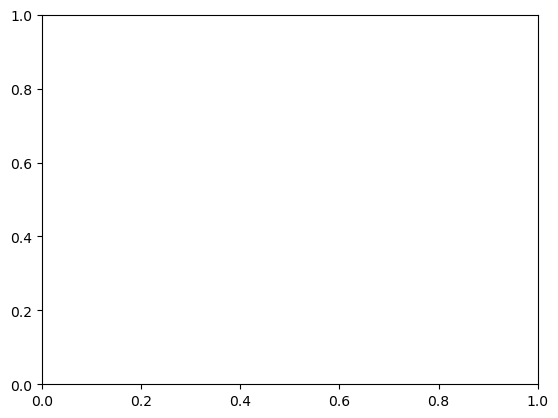

In [9]:
### check scaling by dimension
from scipy.interpolate import BSpline, make_interp_spline
from scipy.ndimage import gaussian_filter1d
import time 
import matplotlib.pyplot as plt
import pandas as pd

'''
num=100
num_dims = 20
low_size=2
high_size=44
dimensions = np.linspace(low_size,high_size, num_dims, dtype=int)
times_dim = []

for i, dim in enumerate(dimensions):
    #initialize kernel
    space = SymmetricPositiveDefiniteMatrices(n = dim)
    kernel = MaternGeometricKernel(space, normalize=False, key=np.random.RandomState())
    params = kernel.init_params()
    params['nu'] = np.array([1.]) #matern kernel
    params['lengthscale']= np.array([1.])

    #generate sample vecs
    mats= gen_spd_sample(num=num, size = dim)
    
    #compute and track
    start_time = time.time()
    kernel_mat = np.around(kernel.K(params,mats),2)
    end_time = time.time()
    times_dim.append(end_time - start_time)
    print(f'Size {i+1} / {num_dims} done.')

#smooth via spline
spl_num= 5
spl_order=3
spl = make_interp_spline(dimensions, times_dim, k=spl_order)
sizes_new = [int(10*i) for i in np.linspace(low_size,high_size,spl_num)]
smooth_spl = spl(sizes_new)

#smooth via gaussian

sizes_gau= dimensions#[1::2]
times_gau = times_dim#[1::2]
smooth_gau = gaussian_filter1d(times_gau, sigma=1.5)
'''
fig, ax = plt.subplots()

ax.plot(sizes_gau, smooth_gau, color='orange')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title(f'Computation time with 1-Matern for {num} samples')
ax.set_xlabel('Sample matrix size')
ax.set_ylabel('Computation time [s]')
plt.savefig('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/scaling_1matern_matsize_100samples_loc2_scale1e.svg', format='svg', dpi=300)
plt.show()

times_series = pd.Series(times_dim)
sizes_series = pd.Series(dimensions)
times_1matern_scaling = pd.concat([sizes_series, times_series], axis=1)
times_1matern_scaling.columns = ['sample_matrix_size','computation_time_seconds']
print(times_1matern_scaling.head())
times_1matern_scaling.to_csv('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/comp_times_1matern_matsize_100samples_loc2_scale1.csv')


In [6]:
### check scaling by smoothness

dim= 10
nu_params = [10**i for i in range(10)]
times_nu = []

#initialize kernel
space = SymmetricPositiveDefiniteMatrices(n = dim)
kernel = MaternGeometricKernel(space, normalize=False, key=np.random.RandomState())
params = kernel.init_params()
params['lengthscale']= np.array([1.])

#generate sample vecs
mats= gen_spd_sample(num=100, dim = dim)

for nu in nu_params:
    
    #change smoothness
    params['nu'] = np.array([nu])

    #compute and track
    start_time = time.time()
    def compute_kernel_time(nu):
        params['nu'] = np.array([nu])
        start_time = time.time()
        kernel_mat = np.around(kernel.K(params, mats), 2)
        end_time = time.time()
        return end_time - start_time

    times_nu = Parallel(n_jobs=-1)(delayed(compute_kernel_time)(nu) for nu in nu_params)
    end_time = time.time()
    times_nu.append(end_time - start_time)
    print(f'Computation for smoothness degree {nu} done.')

#manually for heat kernel
#change smoothness
params['nu'] = np.array([np.inf])

nu_params.append(1e10)

#compute and track
start_time = time.time()
kernel_mat = np.around(kernel.K(params,mats),2)
end_time = time.time()
times_nu.append(end_time - start_time)

#plot times
plt.plot(nu_params, times_nu)
plt.xscale('log')
plt.xticks(nu_params, rotation=90)
plt.xlabel('Smoothness degree [log]')
plt.ylabel('Computation time [s]')
plt.title('Computation time for PDE kernel by smoothness for 100 samples')

#annotate heat kernel
ax= plt.gca()
ticks = ax.get_xticks()
tick_labels = [f"{tick:.0e}" if tick != 1e10 else 'Heat kernel' for tick in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)

plt.savefig('/Users/franziskussteinert/Library/Mobile Documents/com~apple~CloudDocs/NTU Singapore/Work/Comp/comp_time_by_smooth_pdekernel.jpeg', format='jpeg', dpi=300)
plt.show()

TypeError: gen_spd_sample() got an unexpected keyword argument 'dim'